# 01 · Exploring competition around Tec de Monterrey, Campus Monterrey

**Goal:** understand which student-oriented businesses are over- or under-supplied within walking distance of the campus, before adding demand data in phase 2.

**Input:** `data/processed/metro_businesses.parquet`, built by `src/build_study_area.py` from INEGI's DENUE (Nuevo León).

**Sections**
1. Data quality
2. Supply by distance ring
3. Location quotient: Tec vs. the Monterrey metro
4. Benchmark against UANL and UDEM
5. Where are the gaps? A 250 m grid around the campus
6. Interactive map
7. Preliminary findings and next steps

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent
sys.path.append(str(ROOT / "src"))
from config import CAMPUSES, TARGET_CAMPUS
from build_study_area import haversine_m

df = pd.read_parquet(ROOT / "data/processed/metro_businesses.parquet")
lq = pd.read_csv(ROOT / "data/processed/category_by_zone.csv", index_col="categoria")
DIST = f"dist_{TARGET_CAMPUS}_m"

# Chart styling (validated categorical palette, light mode)
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3de"
BLUE, ORANGE, AQUA, NEUTRAL = "#2a78d6", "#eb6834", "#1baf7a", "#b5b4ae"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID,
    "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})
pd.set_option("display.max_colwidth", 80)
print(f"{len(df):,} businesses in the Monterrey metro")

173,829 businesses in the Monterrey metro


## 1. Data quality
The cleaning log written by the pipeline. Every row removed is accounted for.

In [2]:
print((ROOT / "data/processed/data_quality_report.txt").read_text())
df.isna().mean().mul(100).round(2).rename("% missing").to_frame().T

Raw rows (Nuevo León): 211,349
Rows in Monterrey metro: 173,831
Duplicate ids removed: 0
Rows dropped for missing/out-of-range coordinates: 2
Businesses within 500 m of tec_campus_monterrey: 302
Businesses within 1000 m of tec_campus_monterrey: 926
Businesses within 2000 m of tec_campus_monterrey: 4,196



,id,nom_estab,codigo_act,nombre_act,per_ocu,municipio,ageb,latitud,longitud,fecha_alta,municipio_norm,categoria,dist_tec_campus_monterrey_m,dist_uanl_ciudad_universitaria_m,dist_udem_san_pedro_m
% missing,0.0,0.09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Supply by distance ring
How many competitors of each type are within 500 m, 1 km and 2 km of the campus? `otro` groups every activity outside the student-oriented categories.

In [3]:
rings = pd.DataFrame({
    f"≤ {r} m": df[df[DIST] <= r]["categoria"].value_counts() for r in (500, 1000, 2000)
}).fillna(0).astype(int).sort_values("≤ 1000 m", ascending=False)
rings

,≤ 500 m,≤ 1000 m,≤ 2000 m
categoria,,,
otro,134,512,2839
restaurante,82,180,491
belleza_barberia,31,89,292
cafeteria,19,33,82
lavanderia,11,31,53
minisuper_conveniencia,6,28,79
farmacia,6,14,40
abarrotes,2,12,193
gimnasio,3,12,29


## 3. Location quotient: Tec vs. the Monterrey metro

**LQ = (category share within 1 km of the campus) ÷ (category share across the metro).**
LQ > 1 means over-represented near the Tec, LQ < 1 means under-represented. The x-axis is logarithmic so that 0.5× and 2× sit at the same distance from 1.

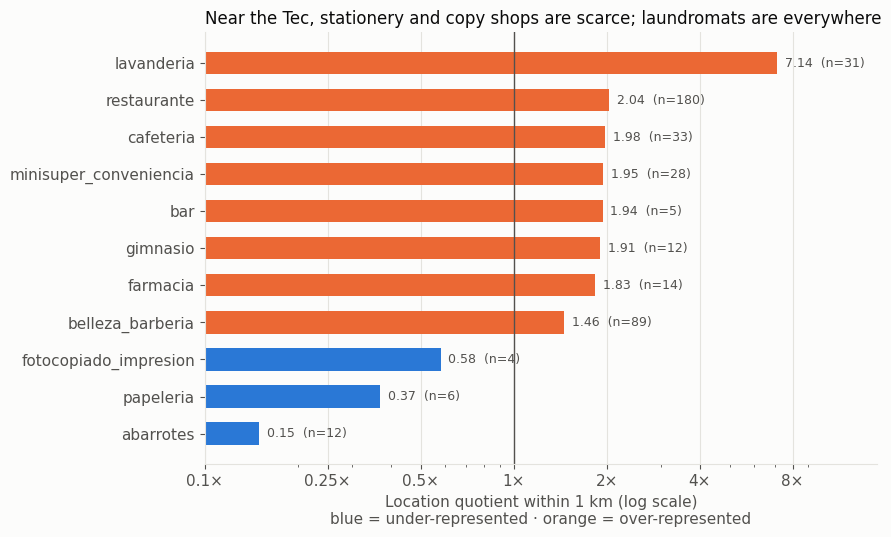

In [4]:
plot = lq.drop(index="otro").sort_values(f"lq_{TARGET_CAMPUS}")
vals = plot[f"lq_{TARGET_CAMPUS}"]
counts = plot[TARGET_CAMPUS]
colors = [BLUE if v < 1 else ORANGE for v in vals]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(plot.index, vals, left=0, color=colors, height=0.6)
ax.set_xscale("log")
ax.axvline(1, color=INK_2, lw=1)
for y, (v, n) in enumerate(zip(vals, counts)):
    ax.text(v * 1.06, y, f"{v:.2f}  (n={n})", va="center", color=INK_2, fontsize=9)
ax.set_xlim(0.1, 15)
ax.set_xticks([0.1, 0.25, 0.5, 1, 2, 4, 8])
ax.set_xticklabels(["0.1×", "0.25×", "0.5×", "1×", "2×", "4×", "8×"])
ax.grid(axis="x", color=GRID, lw=0.8)
ax.set_axisbelow(True)
ax.set_title("Near the Tec, stationery and copy shops are scarce; laundromats are everywhere",
             loc="left", fontsize=12, color=INK)
ax.set_xlabel("Location quotient within 1 km (log scale)\nblue = under-represented · orange = over-represented")
fig.tight_layout()
fig.savefig(ROOT / "docs/lq_tec.png", dpi=150, bbox_inches="tight")
plt.show()

**Read with care:** n is the number of businesses within 1 km. With n = 4 or 6, one extra shop moves the LQ a lot.

## 4. Benchmark against UANL and UDEM
Is a pattern specific to the Tec, or normal around any university?

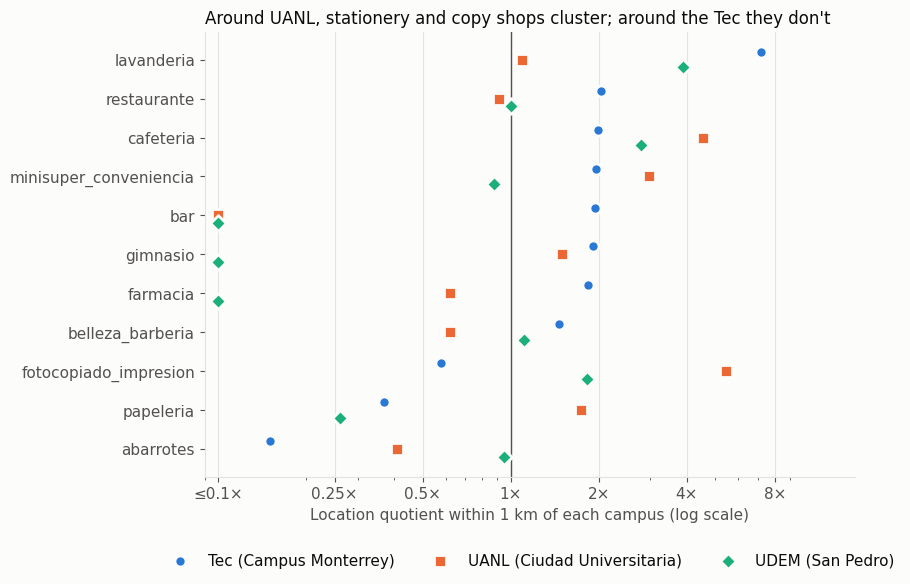

,Tec (Campus Monterrey),UANL (Ciudad Universitaria),UDEM (San Pedro)
categoria,,,
abarrotes,0.15,0.41,0.95
papeleria,0.37,1.74,0.26
fotocopiado_impresion,0.58,5.46,1.82
belleza_barberia,1.46,0.62,1.11
farmacia,1.83,0.62,0.00
gimnasio,1.91,1.50,0.00
bar,1.94,0.00,0.00
minisuper_conveniencia,1.95,2.96,0.88
cafeteria,1.98,4.55,2.78


In [5]:
bench = lq.drop(index="otro")[[f"lq_{c}" for c in CAMPUSES]]
bench.columns = ["Tec (Campus Monterrey)", "UANL (Ciudad Universitaria)", "UDEM (San Pedro)"]
bench = bench.loc[plot.index]

fig, ax = plt.subplots(figsize=(9, 6))
ypos = np.arange(len(bench))
for (label, color, marker, dy) in zip(bench.columns, [BLUE, ORANGE, AQUA], ["o", "s", "D"], [0.2, 0, -0.2]):
    x = bench[label].replace(0, 0.1)  # zero counts drawn at the axis floor
    ax.scatter(x, ypos + dy, s=64, color=color, marker=marker, label=label,
               edgecolor=SURFACE, linewidth=2, zorder=3)
ax.set_xscale("log")
ax.axvline(1, color=INK_2, lw=1)
ax.set_xlim(0.09, 15)
ax.set_xticks([0.1, 0.25, 0.5, 1, 2, 4, 8])
ax.set_xticklabels(["≤0.1×", "0.25×", "0.5×", "1×", "2×", "4×", "8×"])
ax.grid(axis="x", color=GRID, lw=0.8)
ax.set_axisbelow(True)
ax.set_yticks(ypos)
ax.set_yticklabels(bench.index)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3)
ax.set_title("Around UANL, stationery and copy shops cluster; around the Tec they don't",
             loc="left", fontsize=12, color=INK)
ax.set_xlabel("Location quotient within 1 km of each campus (log scale)")
fig.tight_layout()
fig.savefig(ROOT / "docs/lq_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()
bench.round(2)

## 5. Where are the gaps? A 250 m grid around the campus

A first, supply-only pass at *where*:
- Cover a 1.5 km radius with 250 m cells.
- **Activity** = businesses of any kind within 250 m of the cell centre (a rough proxy for foot traffic).
- **Gap** = distance from the cell centre to the nearest stationery or copy shop.
- **Candidate cells** = top-quartile activity **and** no stationery/copy shop within 400 m.

Phase 2 will replace the activity proxy with population data from the 2020 Census.

In [6]:
lat0, lon0 = CAMPUSES[TARGET_CAMPUS]
step_lat = 250 / 111_320
step_lon = 250 / (111_320 * np.cos(np.radians(lat0)))
lats = lat0 + np.arange(-6, 7) * step_lat
lons = lon0 + np.arange(-6, 7) * step_lon
grid = pd.DataFrame([(a, b) for a in lats for b in lons], columns=["lat", "lon"])
grid = grid[haversine_m(grid.lat, grid.lon, lat0, lon0) <= 1500].reset_index(drop=True)

local = df[df[DIST] <= 2200]
target = local[local.categoria.isin(["papeleria", "fotocopiado_impresion"])]

def activity(row):
    return int((haversine_m(local.latitud, local.longitud, row.lat, row.lon) <= 250).sum())

def nearest_target(row):
    return float(haversine_m(target.latitud, target.longitud, row.lat, row.lon).min())

grid["activity_250m"] = grid.apply(activity, axis=1)
grid["nearest_stationery_copy_m"] = grid.apply(nearest_target, axis=1).round(0)
threshold = grid.activity_250m.quantile(0.75)
grid["candidate"] = (grid.activity_250m >= threshold) & (grid.nearest_stationery_copy_m > 400)
print(f"{len(grid)} cells · activity threshold (P75) = {threshold:.0f} businesses · {grid.candidate.sum()} candidate cells")
grid[grid.candidate].sort_values("activity_250m", ascending=False)

113 cells · activity threshold (P75) = 83 businesses · 3 candidate cells


,lat,lon,activity_250m,nearest_stationery_copy_m,candidate
16,25.642417,-100.279535,130,524.0,True
22,25.644663,-100.289500,89,571.0,True
23,25.644663,-100.287009,84,504.0,True


## 6. Interactive map
Hover any point for its name and activity. Toggle layers from the control at the top right. The map is also saved to `docs/map_tec.html`. GitHub does not render interactive maps inside notebooks, so open that file in a browser.

In [7]:
import folium

m = folium.Map(location=[lat0, lon0], zoom_start=15, tiles="OpenStreetMap")
for r in (500, 1000):
    folium.Circle([lat0, lon0], radius=r, color=INK_2, weight=1, fill=False, dash_array="6",
                  tooltip=f"{r} m from campus").add_to(m)
folium.Marker([lat0, lon0], tooltip="Tec de Monterrey · Campus Monterrey",
              icon=folium.Icon(color="darkblue", icon="graduation-cap", prefix="fa")).add_to(m)

near = df[df[DIST] <= 1500]
layers = [
    ("Stationery (papelería)", "papeleria", BLUE, True),
    ("Copy & print shops", "fotocopiado_impresion", ORANGE, True),
    ("Laundromats (saturated, for contrast)", "lavanderia", AQUA, True),
]
ctx = folium.FeatureGroup(name="Other student-oriented businesses", show=True)
for _, b in near[~near.categoria.isin([c for _, c, _, _ in layers] + ["otro"])].iterrows():
    folium.CircleMarker([b.latitud, b.longitud], radius=3, color=NEUTRAL, weight=0, fill=True,
                        fill_opacity=0.6, tooltip=f"{b.nom_estab} · {b.categoria}").add_to(ctx)
ctx.add_to(m)
for name, cat, color, show in layers:
    fg = folium.FeatureGroup(name=name, show=show)
    for _, b in near[near.categoria == cat].iterrows():
        folium.CircleMarker([b.latitud, b.longitud], radius=6, color="#ffffff", weight=2, fill=True,
                            fill_color=color, fill_opacity=0.95,
                            tooltip=f"<b>{b.nom_estab}</b><br>{b.nombre_act}<br>{b[DIST]:.0f} m from campus").add_to(fg)
    fg.add_to(m)
cand = folium.FeatureGroup(name="Candidate cells (gap)", show=True)
for _, g in grid[grid.candidate].iterrows():
    folium.Rectangle([[g.lat - step_lat / 2, g.lon - step_lon / 2], [g.lat + step_lat / 2, g.lon + step_lon / 2]],
                     color=INK, weight=1.5, fill=True, fill_opacity=0.08,
                     tooltip=f"Candidate cell · {g.activity_250m} businesses within 250 m · "
                             f"nearest stationery/copy shop {g.nearest_stationery_copy_m:.0f} m").add_to(cand)
cand.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)
m.save(ROOT / "docs/map_tec.html")
m

Map saved to docs/map_tec.html (open it in a browser; GitHub does not render interactive maps).


## 7. Preliminary findings (supply only)

1. **Laundromats are saturated.** 31 within 1 km, 7.1× the metro share. Avoid.
2. **Restaurants and cafés are crowded.** About 2× the metro share. Entry is possible only with a clear differentiator.
3. **Stationery and copy shops are scarce near the Tec.** Stationery is at 0.37× (6 shops) and copy/print at 0.58× (4 shops). The pattern is not generic to universities: around UANL the same categories are over-represented (1.74× and 5.46×).
4. **The grid points south of the campus.** The candidate cells have top-quartile commercial activity and no stationery or copy shop within 400 m.

**Why this is not a recommendation yet**
- Small counts: one shop more or less moves the LQ noticeably.
- Services inside the campus (e.g., university print centres) may not appear in DENUE, and students may print less than at other universities.
- Supply is only half the equation. Demand (residents and students by block) comes next.

**Next steps:** phase 2 adds 2020 Census population by AGEB, then an opportunity score per cell, a Tableau Public dashboard and a one-page business memo.